# Libraries

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


# Loading data

In [95]:
# "Data for ML" (dataset con trasformazioni)
df=pd.read_csv("C:/Users/fccat/Desktop/MUDI Lab/EDA_Output_no_trans.csv") #(Migliore)
#df=pd.read_csv("C:/Users/fccat/Desktop/MUDI Lab/Data for ML.csv", index_col=0)
df

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,...,Terapia farmacologica,Durata ricovero post int,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Deambulazione.1,Ausili,Indice_Funzionale,Indice_Cognitivo
0,1,0,1,0,0,0,1,0,0,0,...,1,15,Istituto,Meno di 3h,84,109,Autonomo,2 canadesi,51.666667,7.0
1,1,0,1,0,0,0,1,0,0,0,...,2,16,Domicilio con parenti,Meno di 3h,100,118,Autonomo,2 canadesi,67.333333,7.0
2,1,1,0,0,0,1,0,0,0,0,...,2,10,Domicilio con parenti,Meno di 3h,84,107,Con supervisore,2 canadesi,57.000000,7.0
3,1,0,1,0,0,0,1,0,0,0,...,1,20,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,61.666667,7.0
4,1,0,0,1,0,1,0,0,0,0,...,0,18,Istituto,Meno di 3h,99,115,Autonomo,2 canadesi,50.666667,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,...,2,12,Domicilio con parenti,Meno di 3h,99,115,Autonomo,2 canadesi,54.333333,7.0
1495,0,0,1,0,0,0,1,0,0,0,...,2,6,Domicilio con parenti,Meno di 3h,95,118,Autonomo,2 canadesi,47.333333,7.0
1496,1,0,0,1,0,1,0,0,1,0,...,2,13,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,64.666667,7.0
1497,0,0,1,0,0,0,1,0,0,0,...,2,5,Domicilio con parenti,Meno di 3h,97,112,Autonomo,2 canadesi,61.333333,7.0


# Target = Durata ricovero CC riabilitazione (regressorio)

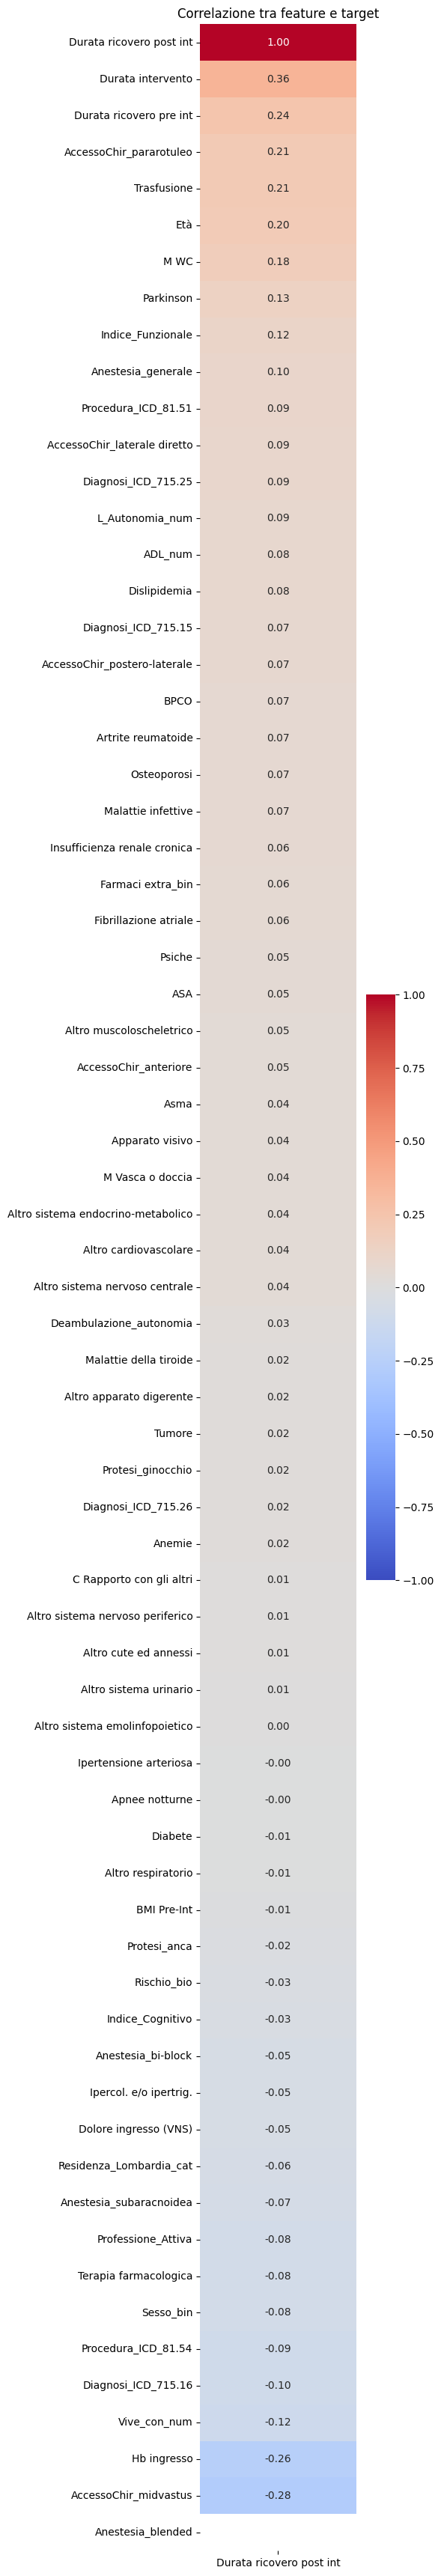

In [ ]:
# Unisci feature e target
data_corr = X_train.copy()
data_corr['Durata ricovero post int'] = y_train

# Calcola correlazione
corr_matrix = data_corr.corr()

# Ordina feature per correlazione con il target
corr_target = corr_matrix[['Durata ricovero post int']].sort_values(by='Durata ricovero post int', ascending=False)

# Plot heatmap con figure più grande e annotazioni leggibili
plt.figure(figsize=(6, len(corr_target)/2))  # altezza dinamica in base al numero di feature
sns.heatmap(corr_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", cbar=True)
plt.title("Correlazione tra feature e target")
plt.tight_layout()
plt.show()


In [96]:
df.columns

Index(['Residenza_Lombardia_cat', 'Diagnosi_ICD_715.15', 'Diagnosi_ICD_715.16',
       'Diagnosi_ICD_715.25', 'Diagnosi_ICD_715.26', 'Procedura_ICD_81.51',
       'Procedura_ICD_81.54', 'AccessoChir_anteriore',
       'AccessoChir_laterale diretto', 'AccessoChir_midvastus',
       'AccessoChir_pararotuleo', 'AccessoChir_postero-laterale', 'Età',
       'Sesso_bin', 'Professione_Attiva', 'BMI Pre-Int',
       'Durata ricovero pre int', 'ASA', 'Durata intervento',
       'Anestesia_bi-block', 'Anestesia_blended', 'Anestesia_generale',
       'Anestesia_subaracnoidea', 'Rischio_bio', 'Trasfusione', 'M WC',
       'M Vasca o doccia', 'C Rapporto con gli altri', 'ADL_num',
       'L_Autonomia_num', 'Deambulazione_autonomia', 'Vive_con_num',
       'Dolore ingresso (VNS)', 'Protesi_anca', 'Protesi_ginocchio',
       'Altro apparato digerente', 'Altro cardiovascolare',
       'Altro cute ed annessi', 'Altro muscoloscheletrico',
       'Altro respiratorio', 'Altro sistema emolinfopoietico',
  

In [97]:
# Lista delle variabili target
targets = [
    "Durata ricovero post int",
    "Outcome sociale",
    "Peso Assistenziale",
    "BI_post_int",
    "FIM_post_int",
    "Deambulazione.1",
    "Ausili"
]

In [98]:
# Dividi in X e y per un target specifico (esempio: 'Outcome sociale')
target = "Durata ricovero post int"
X = df.drop(columns=targets)  # tutte le altre colonne
y = df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
X

Shape X: (1499, 68)
Shape y: (1499,)


,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,...,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapia farmacologica,Indice_Funzionale,Indice_Cognitivo
0,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,9.4,1,51.666667,7.0
1,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,9.0,2,67.333333,7.0
2,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,10.1,2,57.000000,7.0
3,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,8.8,1,61.666667,7.0
4,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,1,0,8.6,0,50.666667,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,12.1,2,54.333333,7.0
1495,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,10.6,2,47.333333,7.0
1496,1,0,0,1,0,1,0,0,1,0,...,0,1,0,0,0,0,9.3,2,64.666667,7.0
1497,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,10.0,2,61.333333,7.0


In [99]:
# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: xlabel='Durata ricovero post int', ylabel='Count'>

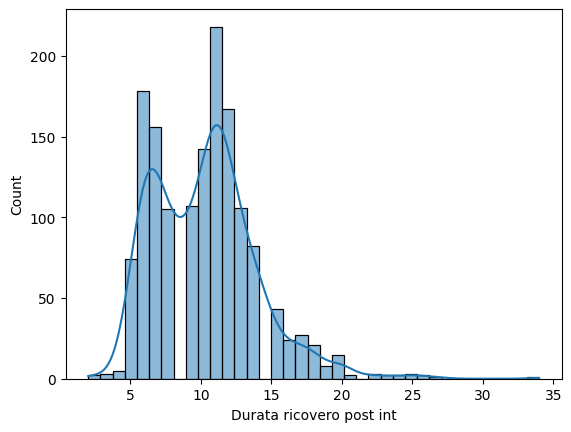

In [100]:
import seaborn as sns
sns.histplot(df["Durata ricovero post int"], kde=True)


<Axes: >

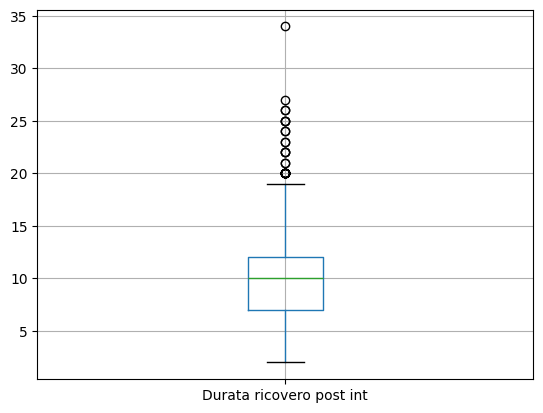

In [101]:
df.boxplot(column=["Durata ricovero post int"])


## Linear Regression

In [102]:
# 4️⃣ Modello di regressione lineare
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
# 5️⃣ Valutazione
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

MAE: 2.41
R²: 0.228


In [104]:
# Se vuoi associare coefficienti ai nomi delle colonne
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
print(coef_df)

# Score R² sul train o test set
print("R² train:", model.score(X_train, y_train))
print("R² test:", model.score(X_test, y_test))

                    Feature  Coefficient
0   Residenza_Lombardia_cat    -0.681063
1       Diagnosi_ICD_715.15     1.067865
2       Diagnosi_ICD_715.16    -0.933122
3       Diagnosi_ICD_715.25     1.456200
4       Diagnosi_ICD_715.26    -1.590943
..                      ...          ...
63        Farmaci extra_bin     0.223207
64              Hb ingresso    -0.289959
65    Terapia farmacologica     0.011869
66        Indice_Funzionale    -0.011700
67         Indice_Cognitivo    -0.517850

[68 rows x 2 columns]
R² train: 0.3119380508060926
R² test: 0.22750567383609488


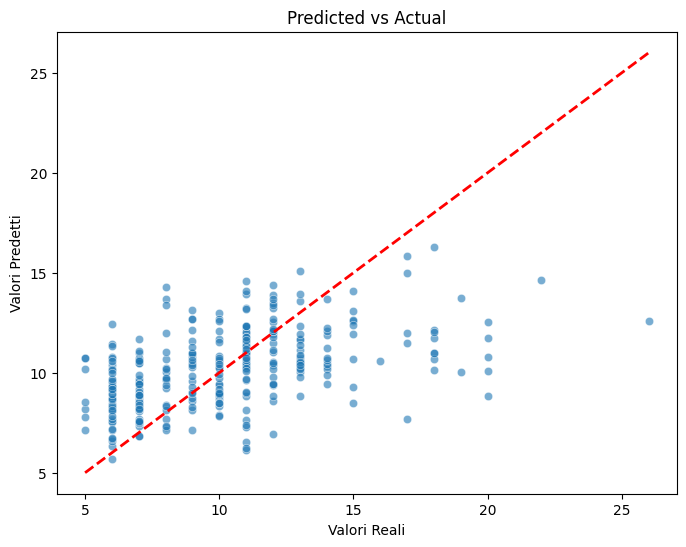

In [105]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual")
plt.show()

In [113]:
print("y_test min/max:", y_test.min(), y_test.max())
print("y_pred min/max:", y_pred.min(), y_pred.max())


y_test min/max: 5 26
y_pred min/max: 5.611855081433593 16.314604433193125


In [ ]:
print(len(X_test), len(y_test), len(y_pred))


300 300 300


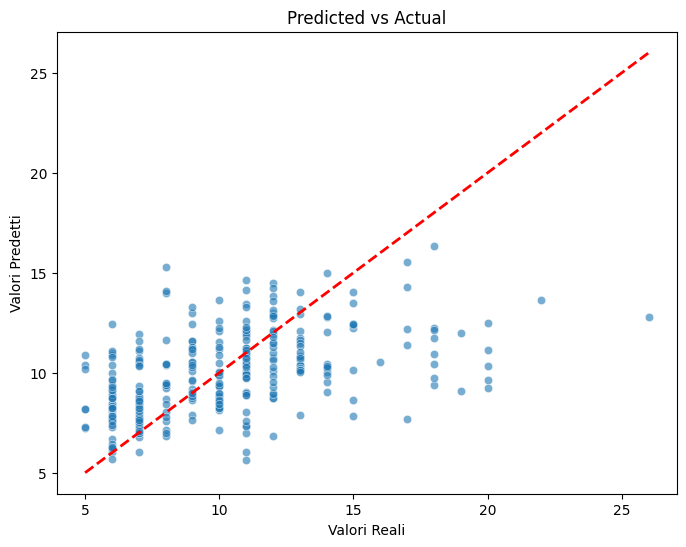

In [116]:
# Assicurati che siano entrambi array 1D
y_test_arr = y_test.values.ravel() if hasattr(y_test, "values") else y_test.ravel()
y_pred_arr = y_pred.ravel()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_arr, y=y_pred_arr, alpha=0.6)
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual")
plt.show()

In [ ]:

diff = y_test.values.ravel() - y_pred.ravel()
print("Differenza media:", np.mean(diff))
print("Differenza min/max:", diff.min(), diff.max())


Differenza media: 0.23409099229487026
Differenza min/max: -7.308250670526322 13.202317745593101


### Cross-Val

In [112]:
# 1️⃣ Definisci il modello
model = LinearRegression()

# 2️⃣ Esegui cross-validation (ad esempio 5-fold)
# Scoring può essere 'r2' per R² o 'neg_mean_absolute_error' per MAE
r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
mae_scores = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

# 3️⃣ Mostra risultati
print(f"R² medio (CV): {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"MAE medio (CV): {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

R² medio (CV): 0.177 ± 0.054
MAE medio (CV): 2.55 ± 0.12


## RandomForest

R² medio (CV): 0.279 ± 0.060
MAE medio (CV): 2.25 ± 0.20

Test set R²: 0.270
Test set MAE: 2.22


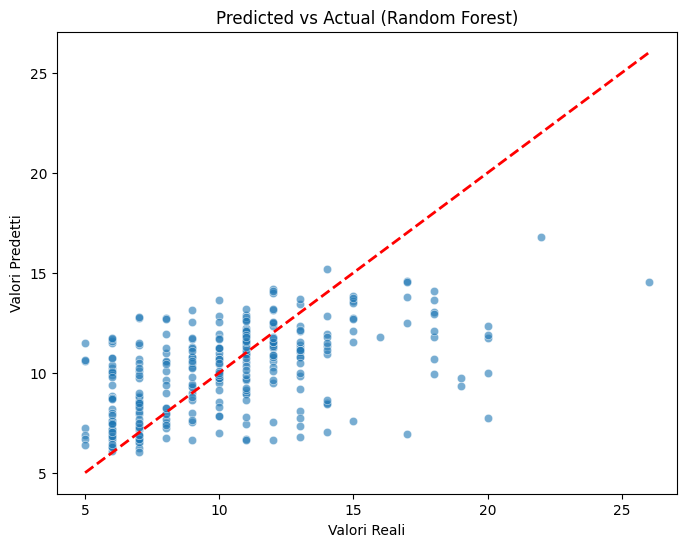

In [126]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# 1️⃣ Definisci il modello
rf_model = RandomForestRegressor(
    n_estimators=100,   # numero di alberi
    random_state=42,
    max_depth=None       # lascia che gli alberi crescano completamente
)

# 2️⃣ Cross-validation (5-fold)
r2_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
mae_scores = -cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"R² medio (CV): {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"MAE medio (CV): {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

# 3️⃣ Fit finale sul training set
rf_model.fit(X_train, y_train)

# 4️⃣ Predizioni sul test set
y_pred_rf = rf_model.predict(X_test)

# 5️⃣ Valutazione su test
print(f"\nTest set R²: {r2_score(y_test, y_pred_rf):.3f}")
print(f"Test set MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

# 6️⃣ Grafico Predicted vs Actual
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual (Random Forest)")
plt.show()


## Ensemble LinearReg+RandomForest

R² medio (CV): 0.280 ± 0.051
MAE medio (CV): 2.32 ± 0.16

Test set R²: 0.297
Test set MAE: 2.23


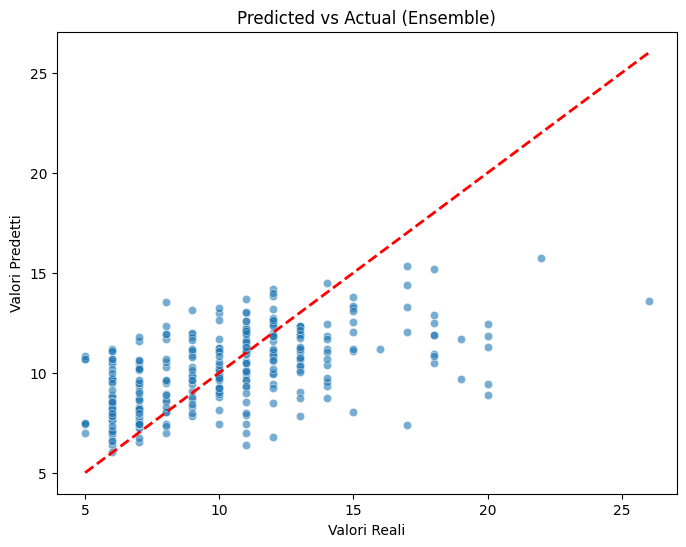

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Definisci i modelli base
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)


# 2️⃣ Crea l'ensemble (Voting Regressor)
ensemble_model = VotingRegressor([('lr', lr), ('rf', rf)])

# 3️⃣ Pipeline: scaling + ensemble
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # scaling necessario per LinearRegression
    ('ensemble', ensemble_model)
])

# 4️⃣ Cross-validation (5-fold)
r2_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"R² medio (CV): {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"MAE medio (CV): {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

# 5️⃣ Fit finale sul training set
pipeline.fit(X_train, y_train)

# 6️⃣ Predizioni sul test set
y_pred_ensemble = pipeline.predict(X_test)

# 7️⃣ Valutazione su test
r2_test = r2_score(y_test, y_pred_ensemble)
mae_test = mean_absolute_error(y_test, y_pred_ensemble)

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set MAE: {mae_test:.2f}")

# 8️⃣ Grafico Predicted vs Actual
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_ensemble, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual (Ensemble)")
plt.show()


## XGBoost

R² medio (CV): 0.176 ± 0.087
MAE medio (CV): 2.46 ± 0.23

Test set R²: 0.234
Test set MAE: 2.37


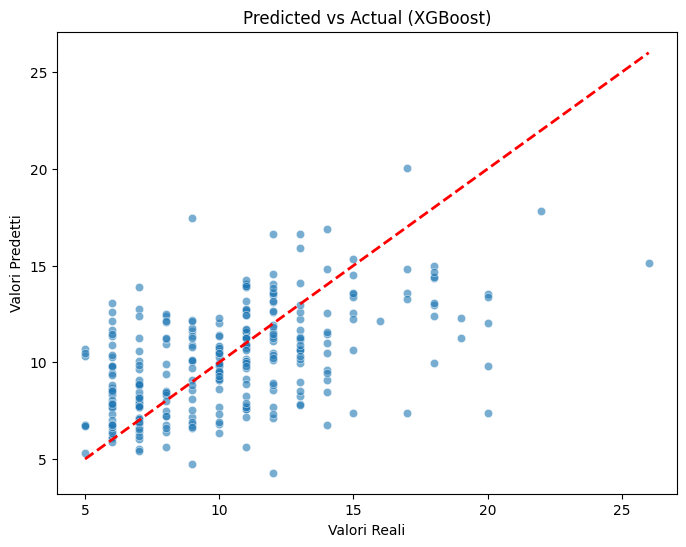

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Definisci il modello XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    verbosity=0,
    objective='reg:squarederror'
)

# 2️⃣ Pipeline (opzionale: scaling, ma non obbligatorio per XGBoost)
pipeline = Pipeline([  # opzionale
    ('xgb', xgb_model)
])

# 3️⃣ Cross-validation (5-fold)
r2_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"R² medio (CV): {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"MAE medio (CV): {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

# 4️⃣ Fit finale sul training set
pipeline.fit(X_train, y_train)

# 5️⃣ Predizioni sul test set
y_pred_xgb = pipeline.predict(X_test)

# 6️⃣ Valutazione su test
r2_test = r2_score(y_test, y_pred_xgb)
mae_test = mean_absolute_error(y_test, y_pred_xgb)

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set MAE: {mae_test:.2f}")

# 7️⃣ Grafico Predicted vs Actual
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual (XGBoost)")
plt.show()


## Support Vector Regression (SVR) con kernel RBF

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Migliori parametri: {'svr__C': 1, 'svr__epsilon': 1, 'svr__gamma': 0.01}
Miglior R² CV: 0.23102571154238954
Test set R²: 0.208
Test set MAE: 2.35


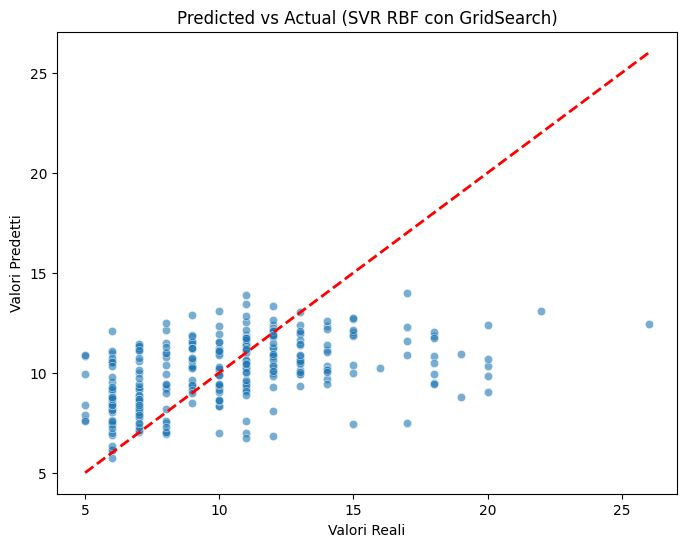

In [139]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Pipeline base
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

# 2️⃣ Definisci la griglia dei parametri
param_grid = {
    'svr__C': [0.1, 1, 10, 100, 1000,10000],
    'svr__gamma': [0.00001,0.0001,0.001, 0.01, 0.1, 1,10,100,1000,10000],
    'svr__epsilon': [0.00001,0.0001, 0.001, 0.01, 0.1, 0.5,1,10,1000,10000]
}

# 3️⃣ GridSearchCV con 5-fold cross-validation
grid_search = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4️⃣ Fit sul training set
grid_search.fit(X_train, y_train)

# 5️⃣ Migliori parametri
print("Migliori parametri:", grid_search.best_params_)
print("Miglior R² CV:", grid_search.best_score_)

# 6️⃣ Predizioni sul test set con il miglior modello
y_pred_svr = grid_search.best_estimator_.predict(X_test)

# 7️⃣ Valutazione su test
r2_test = r2_score(y_test, y_pred_svr)
mae_test = mean_absolute_error(y_test, y_pred_svr)

print(f"Test set R²: {r2_test:.3f}")
print(f"Test set MAE: {mae_test:.2f}")

# 8️⃣ Grafico Predicted vs Actual
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predicted vs Actual (SVR RBF con GridSearch)")
plt.show()
